<a href="https://www.kaggle.com/code/alexvmt/train-and-evaluate-terainet?scriptVersionId=335680929" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/alexvmt/train-and-evaluate-terainet?scriptVersionId=321189515" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Train and evaluate TeraiNet

1. Set variables and parameters
2. Prepare train, val and test datasets
3. Prepare model
4. Train model
5. Evaluate model
6. Log run to W&B

## Setup

### Change working directory

In [1]:
%cd ../../

/


### Clone TeraiNet repo

In [2]:
!git clone https://github.com/alexvmt/terainet.git

Cloning into 'terainet'...
remote: Enumerating objects: 787, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 787 (delta 6), reused 3 (delta 1), pack-reused 708 (from 1)
Receiving objects: 100% (787/787), 12.49 MiB | 19.95 MiB/s, done.
Resolving deltas: 100% (435/435), done.


### Imports

Follow [mewc-flow](https://github.com/zaandahl/mewc-flow/blob/main/requirements.txt) for the key package versions

In [3]:
%pip install keras==3.3.3 kimm==0.2.5 tensorflow==2.16.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 4.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, display
from kaggle_secrets import UserSecretsClient

project_dir = Path("terainet")
sys.path.insert(0, str(project_dir / "src"))

from terainet import (
    build_model,
    create_datasets,
    evaluate_dataset,
    load_training_config,
    log_run_to_wandb,
    prepare_training_data,
    save_evaluation_artifacts,
    set_random_seed,
    train_and_save,
)

INFO:numexpr.utils:NumExpr defaulting to 4 threads.


### Set variables and parameters

In [5]:
training_config_path = project_dir / "training.yaml"
config = load_training_config(training_config_path)

# Kaggle-specific authentication remains in the notebook. Source code only logs
# through an already authenticated W&B session.
use_wandb_logging = config.wandb.get("enabled", False)

In [6]:
# log in to w&b using api key
if use_wandb_logging:
    user_secrets = UserSecretsClient()
    key = user_secrets.get_secret("wandb")
    !wandb login $key

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  pid, fd = os.forkpty()


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


## Prepare train, val and test datasets

### Filter to keep only single-snippet images

In [7]:
set_random_seed(config.seed)
preparation = prepare_training_data(config)

if preparation.filter_stats:
    for subset, stats in preparation.filter_stats.items():
        print(
            f"{subset}: {stats['original_total']} → {stats['filtered_total']} "
            f"({stats['removed_total']} removed)"
        )

INFO:terainet.data:Starting filtering for subset 'train'
INFO:terainet.data:Processing subset='train', class='class_1', mode='copy_unchanged'
INFO:terainet.data:Completed subset='train', class='class_1': original=4948, filtered=4948, removed=0, retention=100.00%
INFO:terainet.data:Processing subset='train', class='class_10', mode='filter_single_snippet'
INFO:terainet.data:Completed subset='train', class='class_10': original=2397, filtered=1894, removed=503, retention=79.02%
INFO:terainet.data:Processing subset='train', class='class_2', mode='filter_single_snippet'
INFO:terainet.data:Completed subset='train', class='class_2': original=2014, filtered=1893, removed=121, retention=93.99%
INFO:terainet.data:Processing subset='train', class='class_3', mode='filter_single_snippet'
INFO:terainet.data:Completed subset='train', class='class_3': original=1941, filtered=1841, removed=100, retention=94.85%
INFO:terainet.data:Processing subset='train', class='class_4', mode='filter_single_snippet'
I

### Sample images

### Create datasets

In [8]:
datasets = create_datasets(config, preparation)
print(f"Train element spec: {datasets.train.element_spec}")
print(f"Validation element spec: {datasets.validation.element_spec}")
print(f"Test element spec: {datasets.test.element_spec}")

Found 19482 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.
Found 296 files belonging to 1 classes.
Train element spec: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))
Validation element spec: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))
Test element spec: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))


### Resize (and augment) images

## Prepare model

In [9]:
model_build = build_model(config)
model_build.model.summary(show_trainable=True)

219481518/219481518 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "terainet_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ EfficientNetV2M             │ (None, 7, 7, 1280)    │ 53,150,388 │   N   │
│ (EfficientNetV2M)           │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 10)            │     12,810 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 53,163,198 (202.80 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

## Train model

Follow [mewc-train](https://github.com/zaandahl/mewc-train) for the training parameters

In [10]:
run_result = train_and_save(model_build, datasets, config, preparation)
print(f"Training time (minutes): {run_result.training_time_minutes}")

Epoch 1/50


I0000 00:00:1784193963.334309     108 service.cc:145] XLA service 0x78d8c812f4c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784193963.334374     108 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


   1/2436 ━━━━━━━━━━━━━━━━━━━━ 23:02:05 34s/step - accuracy: 0.0000e+00 - loss: 3.0955

I0000 00:00:1784193974.878930     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2436/2436 ━━━━━━━━━━━━━━━━━━━━ 460s 175ms/step - accuracy: 0.5287 - loss: 1.6621 - val_accuracy: 0.8856 - val_loss: 0.8368 - learning_rate: 1.0000e-04
Epoch 2/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 403s 165ms/step - accuracy: 0.8453 - loss: 0.9333 - val_accuracy: 0.9004 - val_loss: 0.7931 - learning_rate: 1.0000e-04
Epoch 3/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 404s 166ms/step - accuracy: 0.8672 - loss: 0.8752 - val_accuracy: 0.9080 - val_loss: 0.7700 - learning_rate: 1.0000e-04
Epoch 4/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 402s 165ms/step - accuracy: 0.8794 - loss: 0.8469 - val_accuracy: 0.9108 - val_loss: 0.7606 - learning_rate: 1.0000e-04
Epoch 5/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 402s 165ms/step - accuracy: 0.8856 - loss: 0.8316 - val_accuracy: 0.9144 - val_loss: 0.7522 - learning_rate: 1.0000e-04
Epoch 6/50
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 405s 166ms/step - accuracy: 0.8924 - loss: 0.8172 - val_accuracy: 0.9176 - val_loss: 0.7452 - learning_rate: 1.0000e-04
Epoch 7/50
2436/2436 ━━━━━━━━━━━━━━━━━━

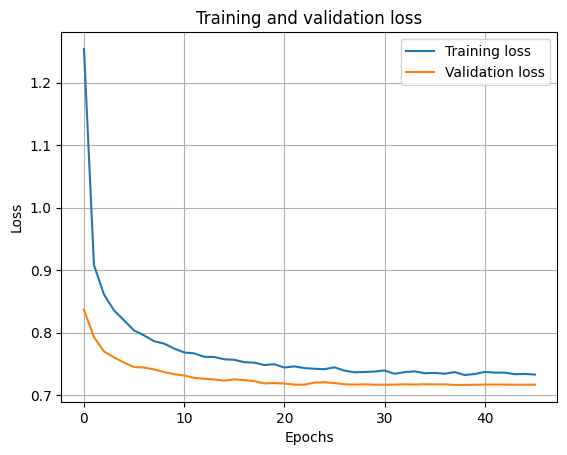

In [11]:
plt.plot(run_result.history.history["loss"], label="Training loss")
plt.plot(run_result.history.history["val_loss"], label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid()
plt.show()

## Evaluate model

### Get predictions on test dataset

In [12]:
test_result = evaluate_dataset(
    run_result.model,
    datasets.test,
    config.class_names,
    name="test",
)
save_evaluation_artifacts(test_result, config)
print(test_result.metrics)

{'accuracy': 0.9348, 'precision_macro': 0.9356398163062266, 'recall_macro': 0.9348000000000001, 'f1_macro': 0.9348699119296635}


In [13]:
ood_result = None
if datasets.ood is not None:
    # OOD data only covers a subset of the configured classes (e.g. tiger-only), so
    # macro precision/recall/f1 are restricted to classes actually present; accuracy
    # remains the primary metric of interest here.
    ood_result = evaluate_dataset(
        run_result.model,
        datasets.ood,
        config.class_names,
        name="ood",
        restrict_macro_to_observed_classes=True,
    )
    print(ood_result.metrics)

{'accuracy': 0.8851351351351351, 'precision_macro': 1.0, 'recall_macro': 0.8851351351351351, 'f1_macro': 0.9390681003584229}


### Get performance metrics, classification report and confusion matrix

In [14]:
print(test_result.report)

                  precision  recall  f1-score  support
tiger              0.996000  0.9960  0.996000    250.0
leopard            0.947368  0.9360  0.941650    250.0
black_bear         0.914397  0.9400  0.927022    250.0
other_carnivores   0.940928  0.8920  0.915811    250.0
deer               0.978448  0.9080  0.941909    250.0
wild_boar          0.929961  0.9560  0.942801    250.0
buffalo            0.885496  0.9280  0.906250    250.0
rhino              0.901141  0.9480  0.923977    250.0
elephant           0.923387  0.9160  0.919679    250.0
bird               0.939271  0.9280  0.933602    250.0
micro avg          0.934800  0.9348  0.934800   2500.0
macro avg          0.935640  0.9348  0.934870   2500.0
weighted avg       0.935640  0.9348  0.934870   2500.0


In [15]:
print(test_result.confusion_matrix)

[[249   0   0   1   0   0   0   0   0   0]
 [  1 234   2   3   1   0   3   4   2   0]
 [  0   2 235   3   1   4   0   2   0   3]
 [  0   4   5 223   2   4   5   4   0   3]
 [  0   4   3   4 227   6   2   1   2   1]
 [  0   0   3   1   0 239   3   0   3   1]
 [  0   2   3   0   0   2 232   3   5   3]
 [  0   0   1   0   0   0   3 237   6   3]
 [  0   1   2   0   0   0   6  11 229   1]
 [  0   0   3   2   1   2   8   1   1 232]]


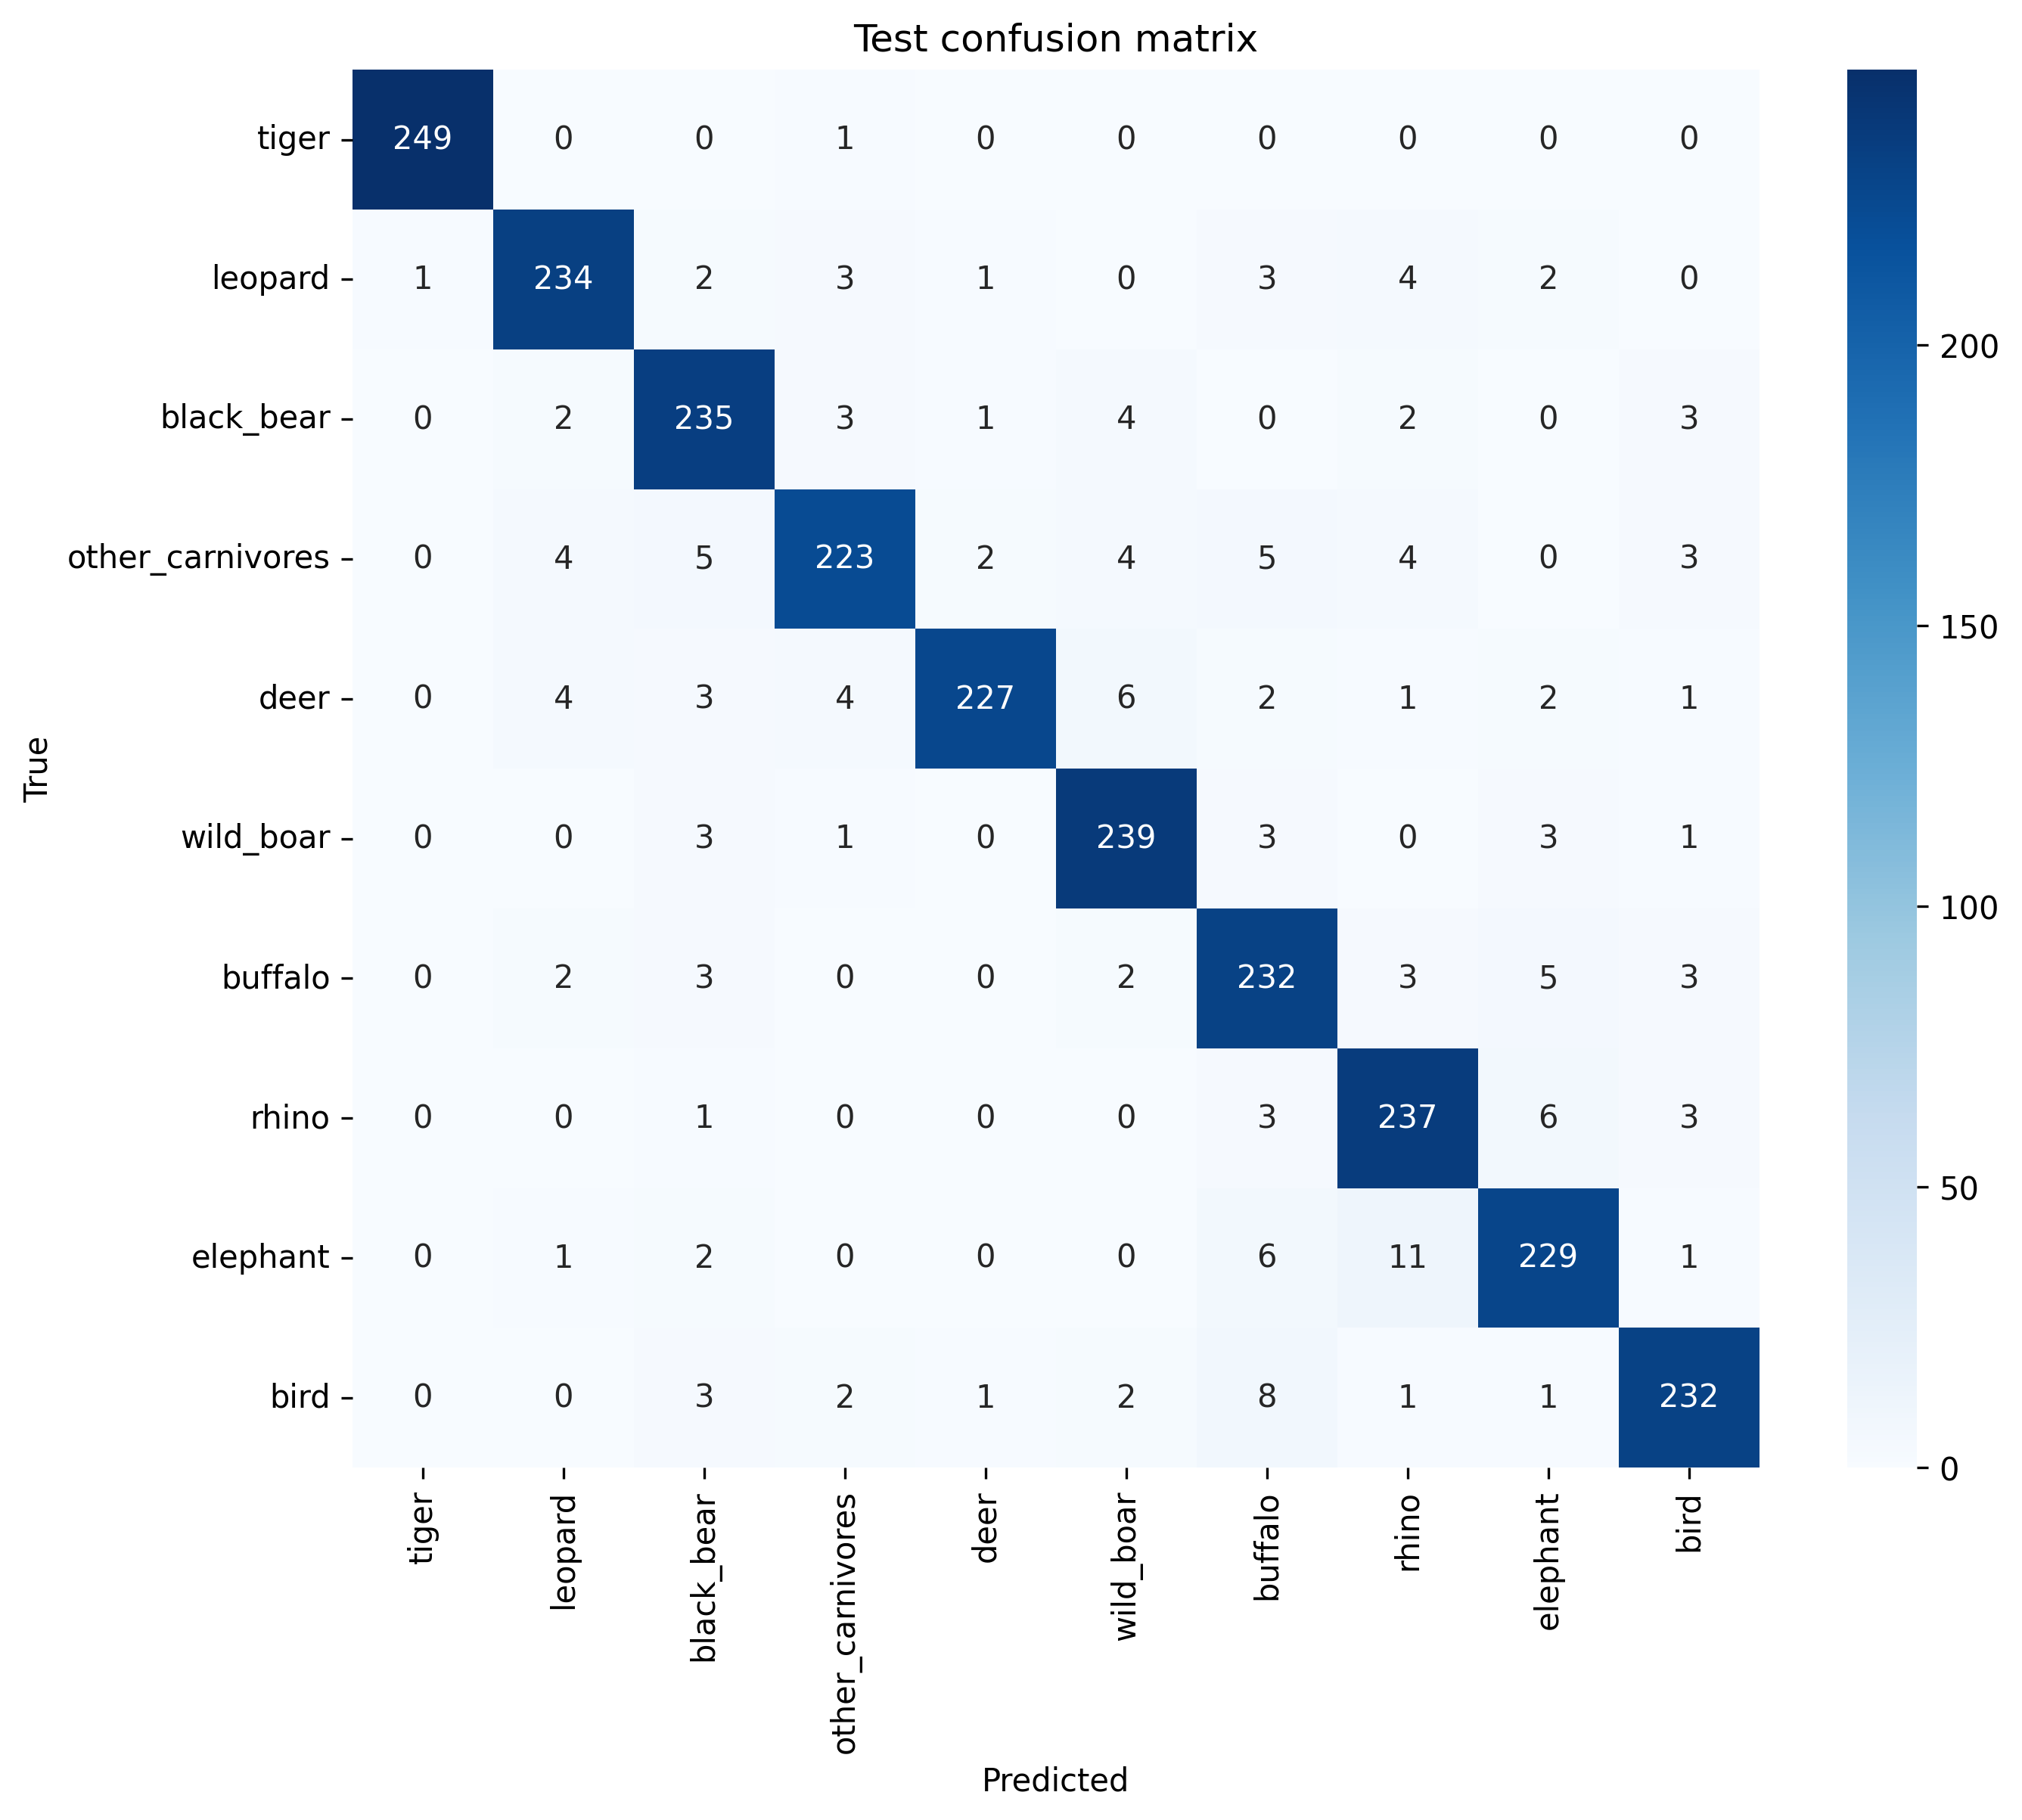

In [16]:
display(Image(filename=config.artifact_paths["confusion_matrix"]))

## Log run to W&B

In [17]:
if use_wandb_logging:
    log_run_to_wandb(config, run_result, test_result, ood_result)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: alexvmt. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.18.7
wandb: Run data is saved locally in /wandb/run-20260716_143731-l77w099r
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run summer-flower-35
wandb: ⭐️ View project at https://wandb.ai/alexvmt/TeraiNet
wandb: 🚀 View run at https://wandb.ai/alexvmt/TeraiNet/runs/l77w099r
wandb:                                                                                
wandb: 
wandb: Run history:
wandb:          ood/accuracy ▁
wandb:          ood/f1_macro ▁
wandb:   ood/precision_macro ▁
wandb:      ood/recall_macro ▁
wandb:         test/accuracy ▁
wandb:         test/f1_macro ▁
wandb:  test/precision_macro ▁
wandb:     test/recall_macro ▁
wandb: training_time_minutes ▁
wandb: 
wandb: Run summary:
wandb:          ood/accuracy 0.88514
wandb:        